# Ejercicio 1: Calibración

Apartados 1, 2 y 3 del ejercicio de calibración, usando las imágenes capturadas con la webcam en `code/calibrate/webcam`.

## Apartado 1

Calibración de la cámara mediante varias imágenes del patrón `code/calibrate/pattern.png`, siguiendo el mismo procedimiento que `code/calibrate/calibrate.py`.

In [1]:
import glob
import numpy as np
import cv2   as cv
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow, subplot

def fig(w,h):
    plt.figure(figsize=(w,h))

def readrgb(file):
    return cv.cvtColor(cv.imread(file), cv.COLOR_BGR2RGB)

In [2]:
pattern_size = (9,6)
square_size  = 1

pattern_points = np.zeros((np.prod(pattern_size),3), np.float32)
pattern_points[:,:2] = np.indices(pattern_size).T.reshape(-1,2)
pattern_points *= square_size

images = sorted(glob.glob('../../code/calibrate/webcam/*.png'))
images

['../../code/calibrate/webcam/20260613-115106.png',
 '../../code/calibrate/webcam/20260613-115212.png',
 '../../code/calibrate/webcam/20260613-115216.png',
 '../../code/calibrate/webcam/20260613-115221.png',
 '../../code/calibrate/webcam/20260613-115227.png',
 '../../code/calibrate/webcam/20260613-115230.png',
 '../../code/calibrate/webcam/20260613-115235.png']

In [3]:
obj_points = []
img_points = []
corners_for_show = []

for f in images:
    img = cv.imread(f, cv.IMREAD_GRAYSCALE)
    h, w = img.shape
    found, corners = cv.findChessboardCorners(img, pattern_size)
    if not found:
        print(f'chessboard not found in {f}')
        continue
    term = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_COUNT, 30, 0.1)
    cv.cornerSubPix(img, corners, (5,5), (-1,-1), term)
    img_points.append(corners.reshape(-1,2))
    obj_points.append(pattern_points)
    corners_for_show.append((f, corners))

len(obj_points)

7

Comprobamos la detección del patrón en un par de imágenes:

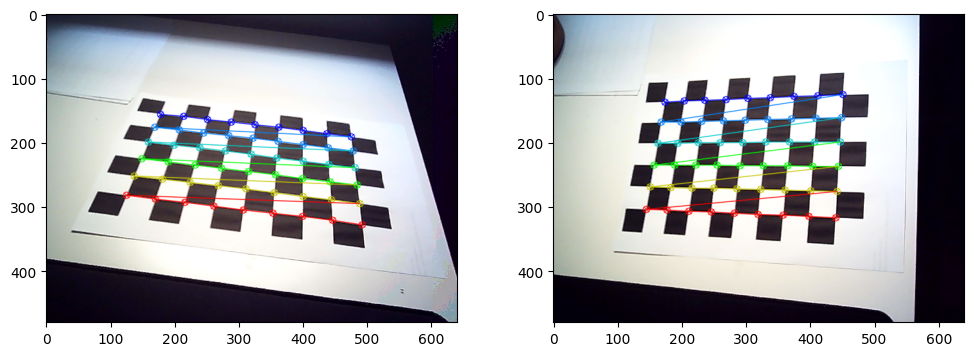

In [4]:
fig(12,4)
for k,(f,corners) in enumerate(corners_for_show[:2]):
    img = readrgb(f)
    cv.drawChessboardCorners(img, pattern_size, corners, True)
    subplot(1,2,k+1)
    imshow(img)

In [5]:
rms, K, dist, rvecs, tvecs = cv.calibrateCamera(obj_points, img_points, (w,h), None, None)

print('RMS:', rms)
print('K:\n', K)
print('dist:', dist.ravel())

RMS: 0.3680904919544285
K:
 [[741.29905122   0.         314.98883356]
 [  0.         743.68640767 267.01856717]
 [  0.           0.           1.        ]]
dist: [ 2.31843332e-02 -1.50098850e+00  8.56170357e-03  8.71466177e-03
  1.34972547e+01]


Guardamos el resultado (misma convención que `calibrate.py`: `K` aplanada seguida de los coeficientes de distorsión) para reutilizarlo en el apartado 3.

In [6]:
np.savetxt('calib.txt', np.concatenate([K.flatten(), dist.flatten()]))

## Apartado 2

A partir de la distancia focal $f$ (elementos $f_x$, $f_y$ de $K$) y la resolución $W\times H$ de la imagen, calculamos el campo visual (FOV) horizontal y vertical.

In [7]:
fx, fy = K[0,0], K[1,1]

hfov = 2*np.degrees(np.arctan2(w/2, fx))
vfov = 2*np.degrees(np.arctan2(h/2, fy))

print(f'Resolución: {w}x{h}')
print(f'FOV horizontal: {hfov:.1f}º')
print(f'FOV vertical:   {vfov:.1f}º')

Resolución: 640x480
FOV horizontal: 46.7º
FOV vertical:   35.8º


## Apartado 3

Script `grid.py` con una cuadrícula de 0.5 m sobre la imagen de la cámara. Los 4 sliders: `fov` (arranca con el valor de `calib.txt`, ~47°), `Z` (distancia al plano en cm), `A` (altura de la cámara en decímetros) y `X` (offset horizontal).

```
./grid.py --dev=0
```

Lo que más costó fue el acoplamiento entre `Z` y `A`: la línea de suelo se proyecta en `fy·H/Z + cy`, así que hay que fijar `A` primero con la altura real medida y luego ajustar `Z`. Si se hace al revés, el `Z` que encaja la cuadrícula no coincide con la distancia real.

Fotos de ejemplo con la cámara a ~30 cm del suelo (`A=3`):

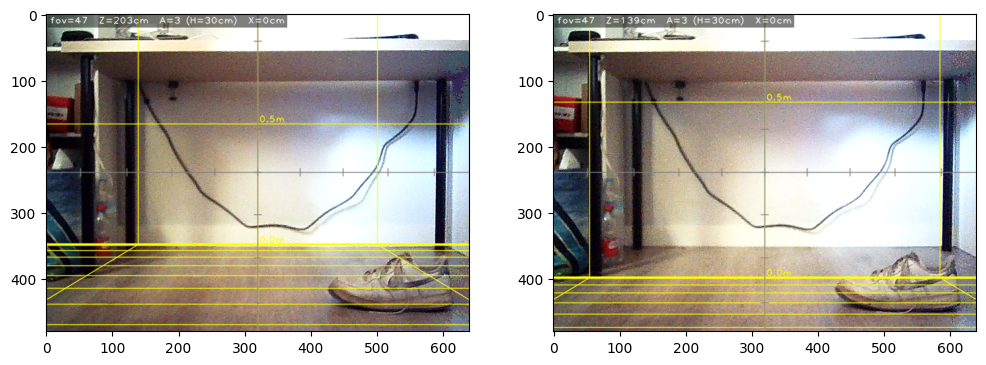

In [8]:
fig(12,5)
subplot(1,2,1)
imshow(readrgb('20260613-124036.png'))
subplot(1,2,2)
imshow(readrgb('20260613-124148.png'))